# 07 Logistische Regression
Deep Dive möglichst noch ohne Hyperparameter Optimierung. Ziel: Entscheidungsfindung für Modelle

## Import

In [9]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.base import clone


import matplotlib as mpl
import matplotlib.pyplot as plt

In [11]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [3]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [4]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Hilfsvariablen

In [12]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

In [13]:
train_times = {}
results = []

In [14]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "trainingszeit": train_time
    }

## L_lr_01

In [16]:
logreg_01 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        verbose=1
    )
)

In [17]:
name = "L_lr_01"

start = time.time()
logreg_01.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [18]:
results.append(eval_modell(name, logreg_01, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,5.486592


In [22]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(logreg_01)
    model.fit(x_sub, y_sub)

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `

,train_size,anteil,auc_train,auc_val
0,47616,0.10,0.650671,0.601601
1,119042,0.25,0.637491,0.610619
2,238084,0.50,0.633127,0.615492
3,357126,0.75,0.632469,0.616342
4,476168,1.00,0.633550,0.616806


Text(0.5, 1.0, 'Learning Curve Logistic Regression')

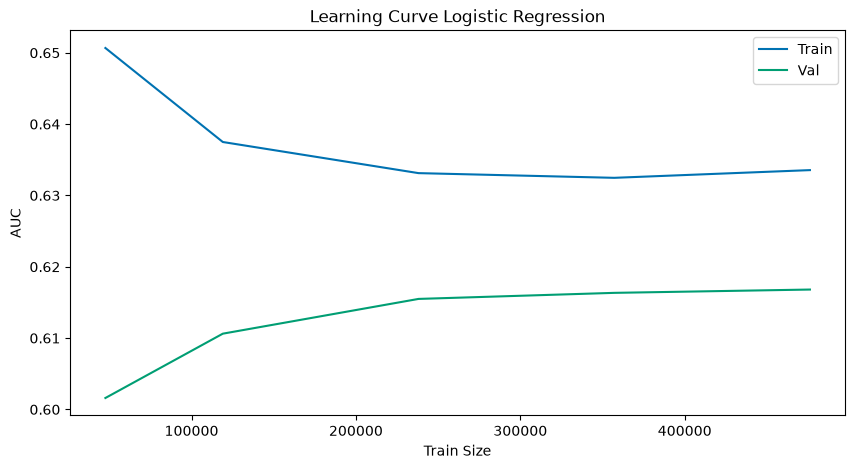

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("Learning Curve Logistic Regression")

## L_lr_02

In [24]:
logreg_02 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [25]:
name = "L_lr_02"

start = time.time()
logreg_02.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [26]:
results.append(eval_modell(name, logreg_02, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,5.486592
L_lr_02,0.634565,0.616952,0.233905,9.314864


In [27]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(logreg_02)
    model.fit(x_sub, y_sub)

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `

,train_size,anteil,auc_train,auc_val
0,47616,0.10,0.655549,0.600811
1,119042,0.25,0.639649,0.610299
2,238084,0.50,0.634815,0.613929
3,357126,0.75,0.633595,0.615900
4,476168,1.00,0.634569,0.617027


Text(0.5, 1.0, 'Learning Curve Logistic Regression')

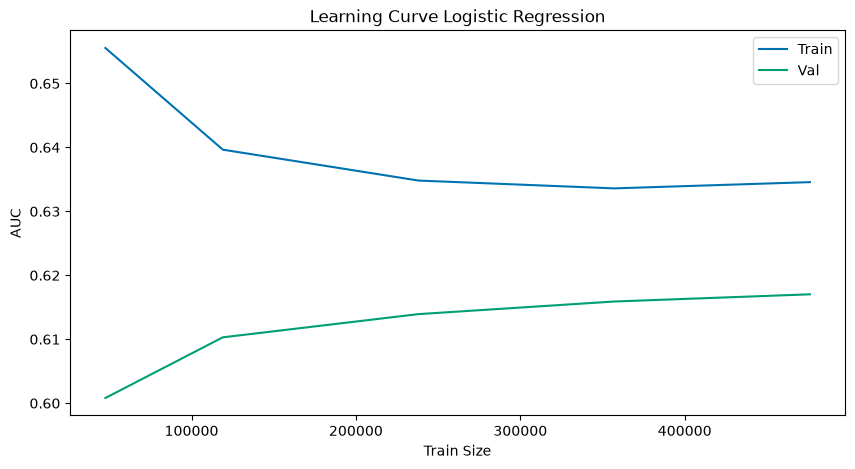

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("Learning Curve Logistic Regression")

## L_lr_03

In [29]:
logreg_03 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [30]:
name = "L_lr_03"

start = time.time()
logreg_03.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [31]:
results.append(eval_modell(name, logreg_03, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,5.486592
L_lr_02,0.634565,0.616952,0.233905,9.314864
L_lr_03,0.634573,0.617071,0.234142,9.392687


## L_lr_04

In [32]:
logreg_04 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            [c for c in bin_cols if c != "ps_ind_06_bin"]
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [33]:
name = "L_lr_04"

start = time.time()
logreg_04.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [34]:
results.append(eval_modell(name, logreg_04, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,5.486592
L_lr_02,0.634565,0.616952,0.233905,9.314864
L_lr_03,0.634573,0.617071,0.234142,9.392687
L_lr_04,0.634597,0.616890,0.233780,10.298857


## L_lr_05

In [40]:
num_cols_v5 = [c for c in num_cols if c not in ("ps_reg_03", "ps_ind_14")]
bin_cols_v5 = [c for c in bin_cols if c != "ps_ind_18_bin"]

logreg_05 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols_v5
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_v5
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [41]:
name = "L_lr_05"

start = time.time()
logreg_05.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [42]:
results.append(eval_modell(name, logreg_05, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,5.486592
L_lr_02,0.634565,0.616952,0.233905,9.314864
L_lr_03,0.634573,0.617071,0.234142,9.392687
L_lr_04,0.634597,0.616890,0.233780,10.298857
L_lr_06,0.634388,0.617334,0.234669,8.266473
L_lr_05,0.633909,0.615165,0.230330,9.247278


## L_lr_06

In [35]:
logreg_06 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols_no_calc
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_no_calc
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [36]:
name = "L_lr_06"

start = time.time()
logreg_06.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [37]:
results.append(eval_modell(name, logreg_06, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,5.486592
L_lr_02,0.634565,0.616952,0.233905,9.314864
L_lr_03,0.634573,0.617071,0.234142,9.392687
L_lr_04,0.634597,0.616890,0.233780,10.298857
L_lr_06,0.634388,0.617334,0.234669,8.266473


## L_lr_07


## Notizen
Punkte aus der EDA, die ich hier behandeln möchte:
|Gedanke|Umsetzung|
|---|---|
|One Hot encodings kolinearität|drop=first im encoding|
|ps_ind_[06,07,08,09]_bin scheinen wie one hots zu funktionieren|eine spalte droppen (andere liefern info zu dieser Spalte)|
|ps_ind_[16,17 bzw 16,18]_bin korrelieren stark negativ|könnte reduziert werden|
|ps_ind_12_bin, ps_ind_14 korrelieren stark|mögliche Redundanz, könnte reduziert werden|
|ps_reg_[02,03] korrelieren stark|mögliche Redundanz, könnte reduziert werden|
|ps_calc_* zeigt kaum signal (in jeder EDA befunden)|könnte gedroppt werden (kaum interkorrelation)|
|Starke Klassenimbalance von target|class_weight="balanced" könnten helfen|


Punkte aus der Aufgabenstellung, die ich hier behandeln möchte:
- Learning Curve vor Modelltraining

Modelle im Notebook:
|Modell Index|Spezifikation
|---|---|
|L_lr_01|Simple aus 06 als Bezugspunkt|
|L_lr_02|class_weight="balanced"|
|L_lr_03|Drop first in onehot|
|L_lr_04|Drop first in onehot und ps_ind_06_bin drop|
|L_lr_05|Umgang mit korrelationen prüfen|
|L_lr_06|calc droppen|
|L_lr_07|Alles Zusammen nicht nötig, bis jetzt 06 am besten|

Bei allen an 02 class_weight="balanced"

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html